<a href="https://colab.research.google.com/github/Aris-27/Machine-Learning/blob/main/machine_learning_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rivo Aris M
# 240210005

In [3]:
# Import packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [4]:
dataframe = pd.read_csv("/content/Rumah.csv.xls")

In [5]:
dataframe.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
print(np.shape(dataframe))

(506, 14)


In [7]:
print(dataframe.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

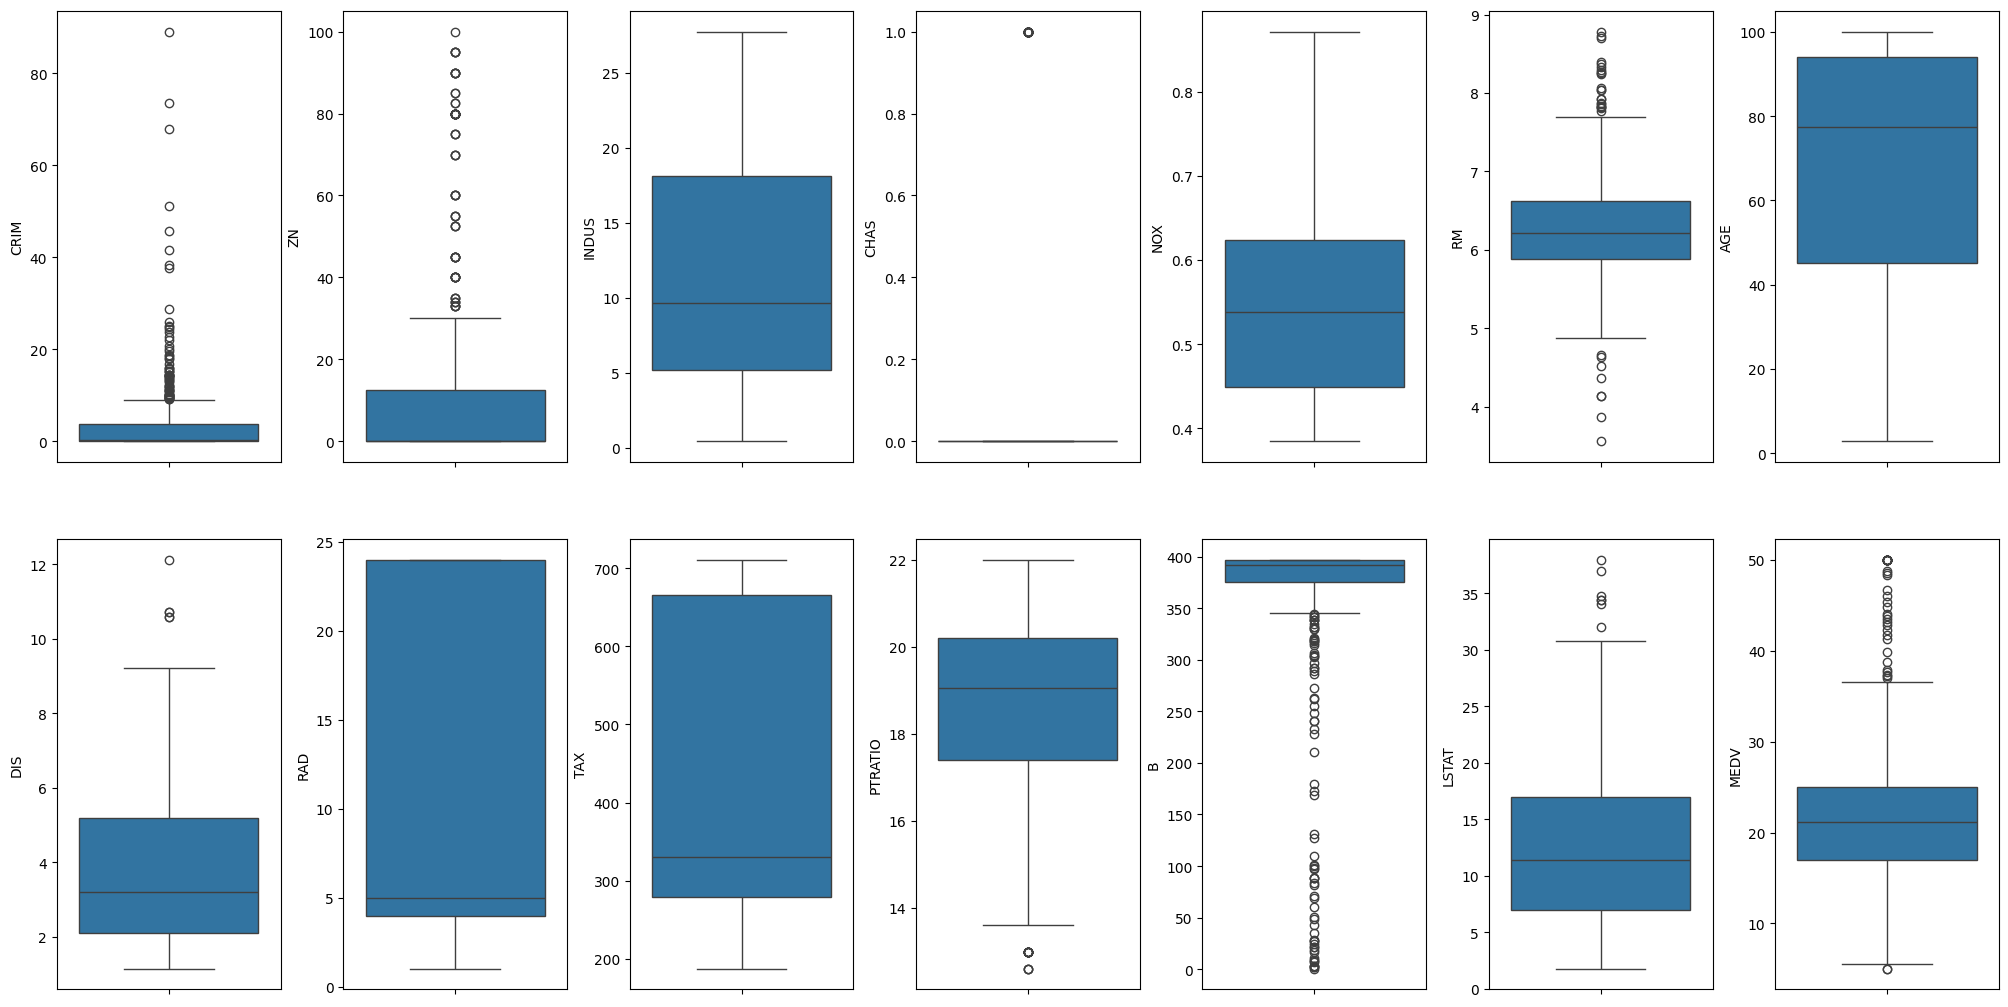

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axs = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
axs = axs.flatten()
index = 0
for k, v in dataframe.items():
    sns.boxplot(y=k, data=dataframe, ax=axs[index])
    index += 1
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()

In [9]:
for k, v in dataframe.items():
    q1 = v.quantile(0.25)
    q3 = v.quantile(0.75)
    iqr = q3 - q1
    lower_outliers = v[v < (q1 - 1.5 * iqr)]
    upper_outliers = v[v > (q3 + 1.5 * iqr)]
    total_outliers = pd.concat([lower_outliers, upper_outliers])
    perc = total_outliers.shape[0] * 100.0 / dataframe.shape[0]
    print("Column %s outliers = %.2f%%" % (k, perc))


Column CRIM outliers = 13.04%
Column ZN outliers = 13.44%
Column INDUS outliers = 0.00%
Column CHAS outliers = 6.92%
Column NOX outliers = 0.00%
Column RM outliers = 5.93%
Column AGE outliers = 0.00%
Column DIS outliers = 0.99%
Column RAD outliers = 0.00%
Column TAX outliers = 0.00%
Column PTRATIO outliers = 2.96%
Column B outliers = 15.22%
Column LSTAT outliers = 1.38%
Column MEDV outliers = 7.91%


In [10]:
dataframe = dataframe[~(dataframe['MEDV'] >= 50.0)]
print(np.shape(dataframe))

(490, 14)


/tmp/ipython-input-2498422865.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(v, ax=axs[index])
/tmp/ipython-input-2498422865.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(v, ax=axs[index])
/tmp/ipython-input-2498422865.py:5: UserWarning: 

`distplot` is a deprecated function and will 

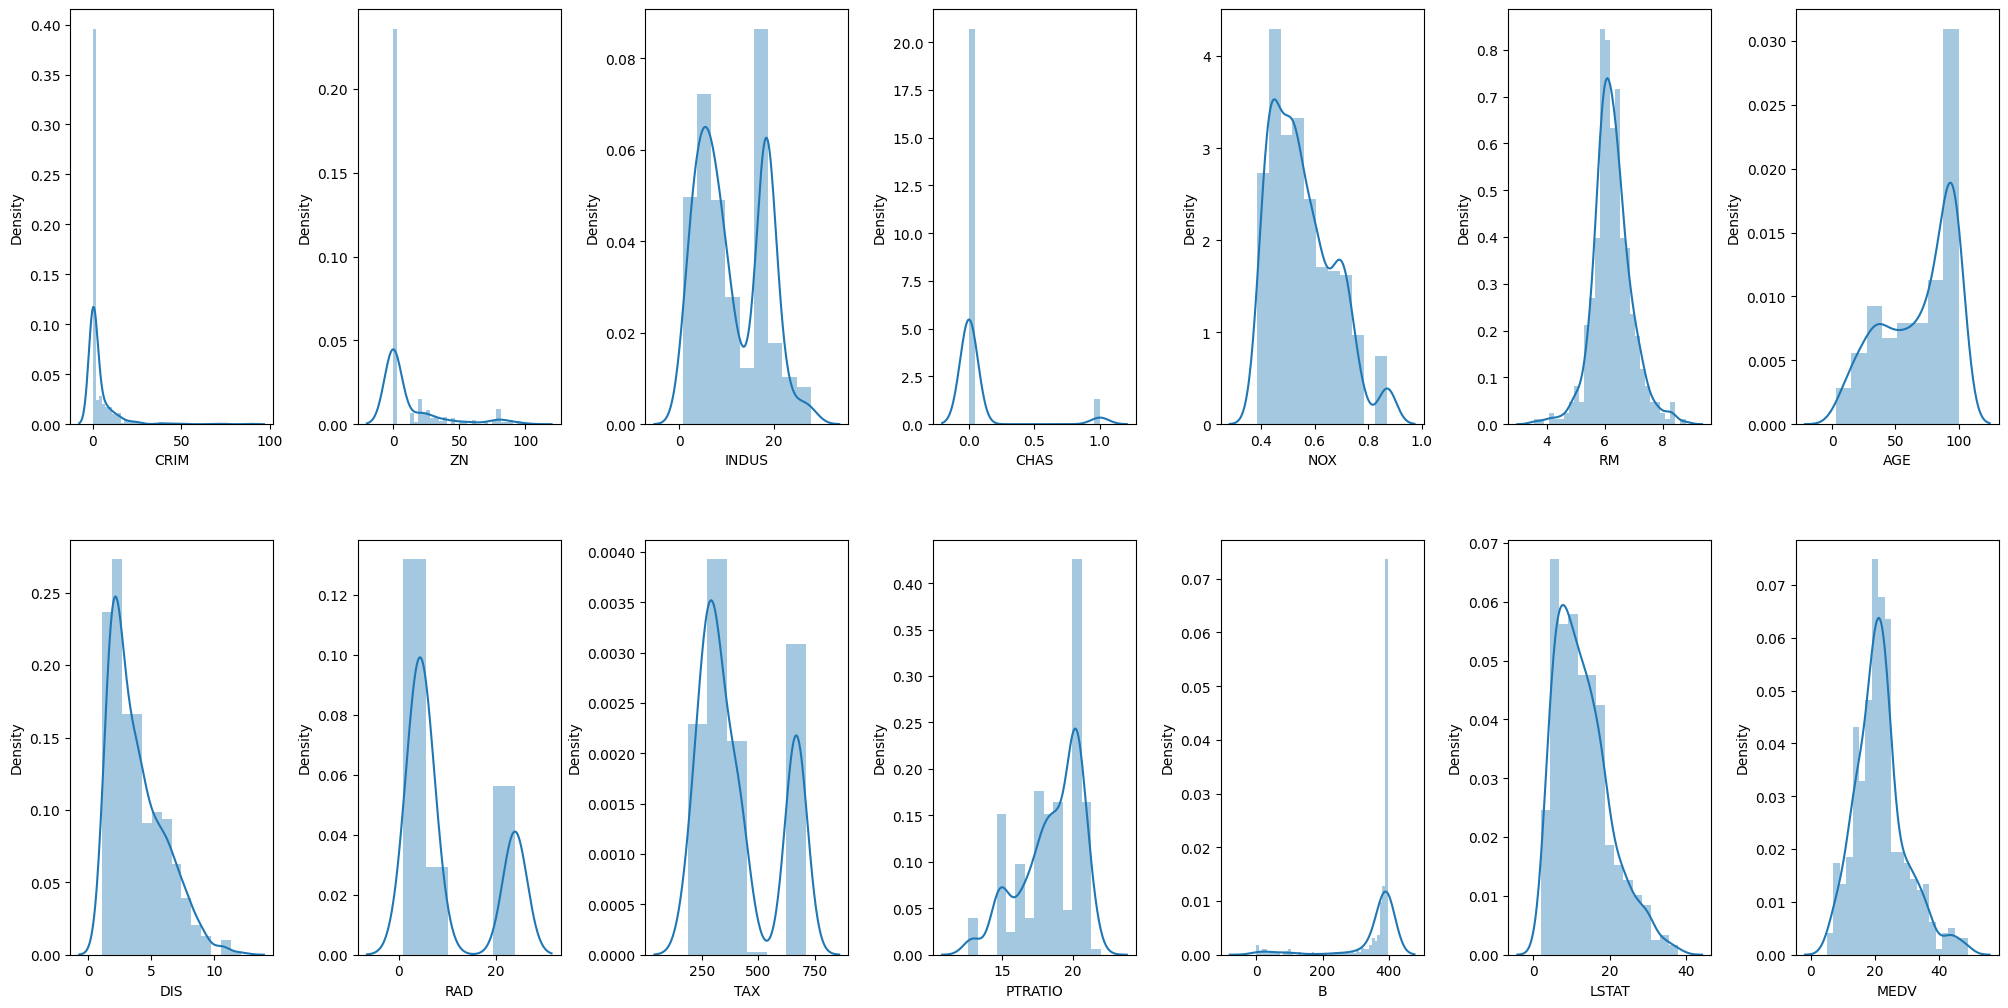

In [11]:
fig, axs = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
index = 0
axs = axs.flatten()
for k, v in dataframe.items():
  sns.distplot(v, ax=axs[index])
  index += 1
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)

<Axes: >

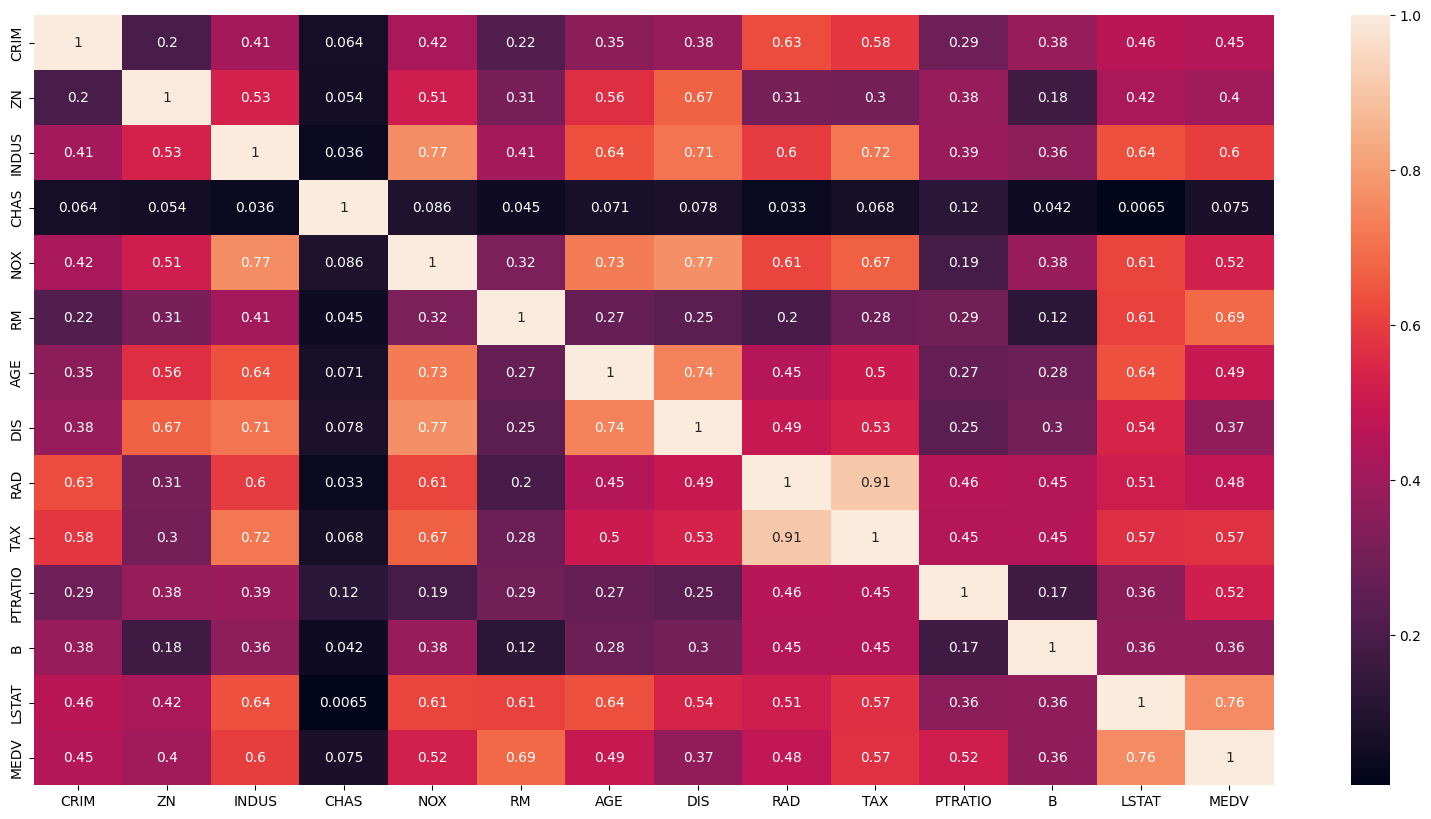

In [12]:
plt.figure(figsize=(20, 10))
sns.heatmap(dataframe.corr().abs(), annot=True)

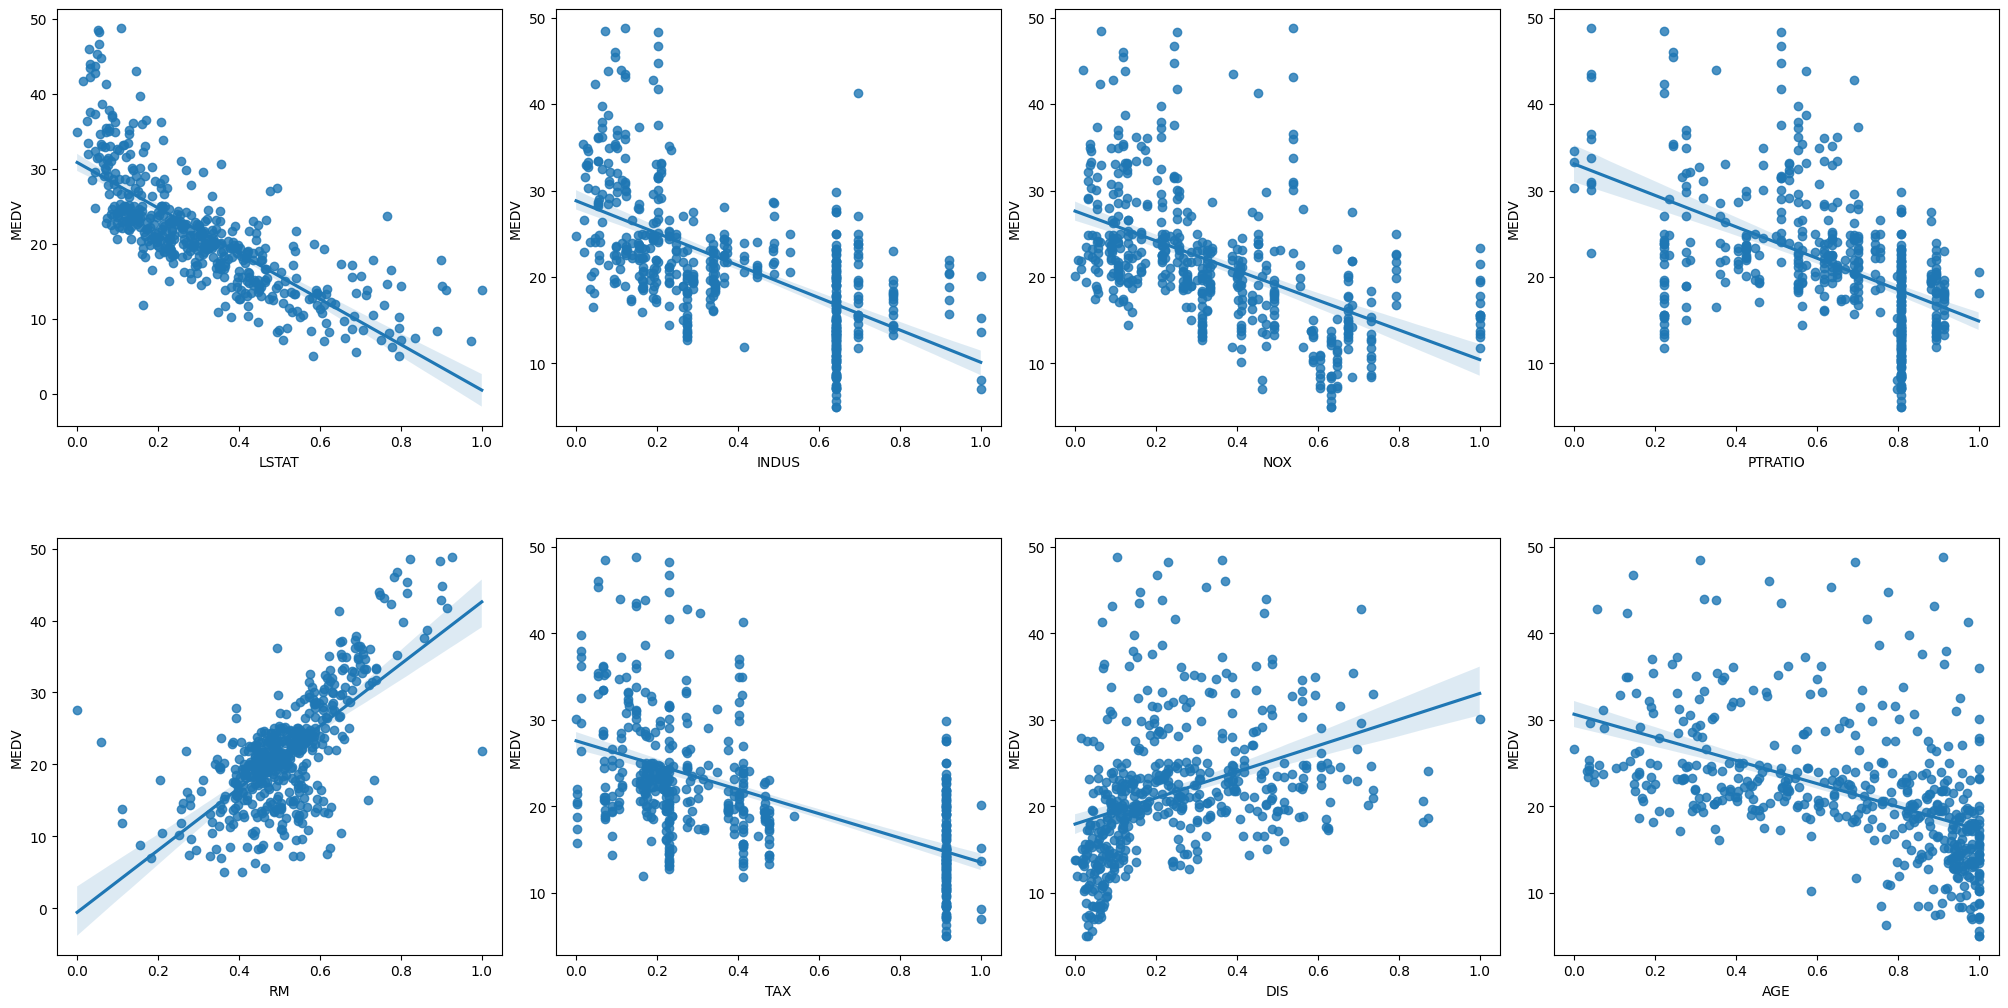

In [13]:
from re import X
from sklearn import preprocessing
min_max_scaler = preprocessing.MinMaxScaler()
column_sels = ['LSTAT', 'INDUS', 'NOX', 'PTRATIO', 'RM', 'TAX', 'DIS', 'AGE']
X = dataframe.loc[:,column_sels]
y = dataframe['MEDV']
X = pd.DataFrame(data=min_max_scaler.fit_transform(X), columns=column_sels)
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(20, 10))
index = 0
axs = axs.flatten()
for i, k in enumerate(column_sels):
  sns.regplot(y=y, x=X[k], ax=axs[i])
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)

In [14]:
y = np.log1p(y)
for col in X.columns:
  if np.abs(X[col].skew()) > 0.1:
    X[col] = np.log1p(X[col])

In [15]:
from sklearn import datasets, linier_model
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
import numpy as np

l_regression = linier_model.LinerRegression
kf = KFold(n_splits=10)
min_max_scaler = preprocessing.MinMaxScaler()
X_scaled = min_max_scaler.fit_transform(X)
scores = cross_val_score(l_regression, X_scaled, y, cv=kf, scoring='neg_mean_squared_error')
print("MSE: %0.2f (+/- 0%.2f)" % (scores.mean(), scoress.std()))

scores_map = ()
scores_map['LinerRegression'] = scores
l_ridge = linier_model.Ridge()
scores = cross_val_score(l_ridge, X_scaled, y, cv=kf, scoring='neg_mean_squared_error')
scores_map['Midge'] - scores
print("MSE: %0.2f (+/- 0%.2f)" % (scores.mean(), scoress.std()))

 #sampai disini saja pak mohon maaf karena fotonya tidak jelas

ImportError: cannot import name 'linier_model' from 'sklearn' (/usr/local/lib/python3.12/dist-packages/sklearn/__init__.py)